# ■ 머신러닝 컴페티션

### 컴페티션의 목표는 ① 이해, ② 풀프로세스 코딩, ③ 설명력을 키우는게 목적입니다.

데이터 출처: https://www.kaggle.com/datasets/gauravtopre/bank-customer-churn-dataset/data

## ■ 공지

※ 모델 성능이 제일 높은 기준으로 채점 X

※ 수업 코드 사용 가능

※ 타 온라인 상 레퍼런스 코드 참고는 가능하나, 통째 복사 금지

※ 학습자 간 상의 절대 금지.

※ 최신 기술 또는 대단한 아이디어 보다. 1. 코딩의 인과성, 2. 설명, 3. 결과 해석에 따른 합당한 인사이트 제안으로 만점이 가능합니다.

</br>

## ■ 평가기준 (총점 90점) ※ 글자 수로 점수 평가 X

1. (15점) 전처리 아이디어 적합성 + 논리 (650자 이내, 주석 서술하기)

2. (20점) EDA를 통한 타당한 해석 (650자 이내, 주석 서술하기)

3. (25점) Feature Selection과 ML 선정 기준 (650자 이내, 주석 서술하기)

4. (25점) SHAP value 사후분석과 인사이트 제안 (650자 이내, 주석 서술하기)

5. (5점 ) validation score 적절하게 출력 (300자 이내, 주석 서술하기)

## ▶ 첫째날, 숙달 Day (감독):

### 18시 까지 코드 완성본 (주석 서술 포함) 제출 (90점) - 시험시작부터 3시간 후 휴식 가능

---

## ▶  둘째날, 포트폴리오화 Day:

### 깃허브에 코드 및 READ ME 이쁘게 정리하여 URL 제출 (10점)

## 레퍼런스 코드 (타이타닉 데이터 버전)

In [ ]:
!pip install matplotlib

In [ ]:
!pip install seaborn

[I 2026-04-09 14:21:37,802] A new study created in memory with name: no-name-431a821e-6dba-43c2-8f41-dc6a95b18293
[I 2026-04-09 14:21:38,061] Trial 0 finished with value: 0.7166666666666667 and parameters: {'n_estimators': 218, 'max_depth': 7}. Best is trial 0 with value: 0.7166666666666667.
[I 2026-04-09 14:21:38,310] Trial 1 finished with value: 0.7424242424242424 and parameters: {'n_estimators': 175, 'max_depth': 13}. Best is trial 1 with value: 0.7424242424242424.
[I 2026-04-09 14:21:38,486] Trial 2 finished with value: 0.734375 and parameters: {'n_estimators': 140, 'max_depth': 9}. Best is trial 1 with value: 0.7424242424242424.
[I 2026-04-09 14:21:38,640] Trial 3 finished with value: 0.7068965517241379 and parameters: {'n_estimators': 153, 'max_depth': 4}. Best is trial 1 with value: 0.7424242424242424.
[I 2026-04-09 14:21:38,886] Trial 4 finished with value: 0.6842105263157895 and parameters: {'n_estimators': 218, 'max_depth': 3}. Best is trial 1 with value: 0.7424242424242424.


RF F1: 0.7480916030534351
LR F1: 0.71875
SVM F1: 0.765625
KNN F1: 0.7536231884057971


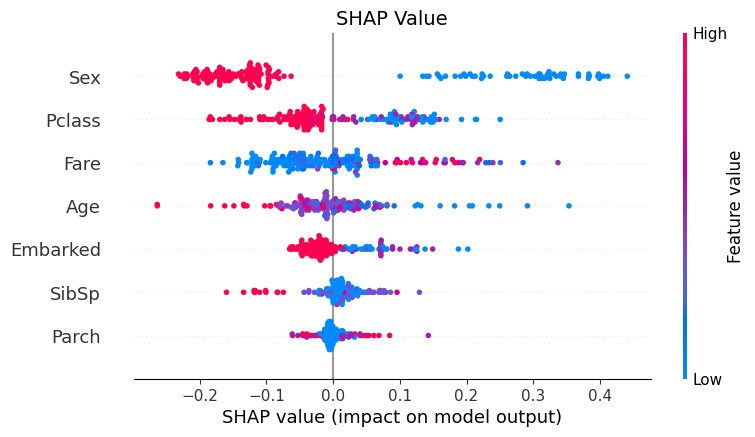

Stacking F1: 0.7580645161290323


In [16]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import f1_score

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

import optuna
import shap
import matplotlib.pyplot as plt

# 데이터 로드
df = pd.read_csv('titanic.csv')

# 전처리
# 필요없는 컬럼 제거
df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], errors='ignore')

# 결측치 처리
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# 범주형 인코딩
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

# ★필독! EDA 제안 해줘야 한다.

# X, y
X = df.drop('Survived', axis=1)
y = df['Survived']

# train valid split
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 스케일링
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)


# ★필독! 모델 선정은 pycaret을 이용해서 스코어 잘나오는 모델 4개 고르기


# Optuna : 하이퍼파라미터 리스트는 구글에 각 모델 검색하면 나온다.
#          (예: 랜덤포레스트 optuna 검색)
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
    }
    model = RandomForestClassifier(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_lr(trial):
    params = {
        'C': trial.suggest_float('C', 0.01, 10)
    }
    model = LogisticRegression(**params, max_iter=1000)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_svm(trial):
    params = {
        'C': trial.suggest_float('C', 0.1, 10),
        'kernel': trial.suggest_categorical('kernel', ['linear', 'rbf'])
    }
    model = SVC(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_knn(trial):
    params = {
        'n_neighbors': trial.suggest_int('n_neighbors', 3, 15)
    }
    model = KNeighborsClassifier(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

# 각 모델마다 옵튜나로 최적의 하이퍼파라미터 탐색
study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=10)

study_lr = optuna.create_study(direction='maximize')
study_lr.optimize(objective_lr, n_trials=10)

study_svm = optuna.create_study(direction='maximize')
study_svm.optimize(objective_svm, n_trials=10)

study_knn = optuna.create_study(direction='maximize')
study_knn.optimize(objective_knn, n_trials=10)

# 옵튜나로 찾은 각각 모델의 하이퍼 파라미터로 각각 모델 옵션 정의
rf = RandomForestClassifier(**study_rf.best_params)
lr = LogisticRegression(**study_lr.best_params, max_iter=1000)
svm = SVC(**study_svm.best_params, probability=True)
knn = KNeighborsClassifier(**study_knn.best_params)

# 모델 학습
rf.fit(X_train, y_train)
lr.fit(X_train, y_train)
svm.fit(X_train, y_train)
knn.fit(X_train, y_train)

# 반복문을 통하여 학습이 완료된 모델 꺼내와서 예측하고 f1스코어 출력
for name, model in [('RF', rf), ('LR', lr), ('SVM', svm), ('KNN', knn)]:
    pred = model.predict(X_valid)
    print(name, "F1:", f1_score(y_valid, pred))

# SHAP - 여기서 랜덤포레스트를 지정해서 사후분석 해보겠다.
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_valid)

# 모델마다 SHAP value 행렬 차원이 다르기 때문에 다르게 설정 (수업에서 강조한 내용)
if isinstance(shap_values, list):
    shap_values = shap_values[1]
elif shap_values.ndim == 3:
    shap_values = shap_values[:, :, 1]
else:
    shap_values = shap_values

# SHAP  Plot 시각화
shap.summary_plot(
    shap_values, # shape value 반환
    X_valid, # 평가용 데이터로 SHAP value 측정
    feature_names=X.columns, # 컬럼리스트
    plot_type="dot",
    show=False
)
plt.title("SHAP Value", fontsize=14)
plt.show()


# 전방 모델 리스트
est_model_list = [
                      ('rf', rf),
                      ('svm', svm),
                      ('knn', knn)
                  ]


# Stacking 모델 합체
stack = StackingClassifier(
    estimators = est_model_list, # 전방모델
    final_estimator = LogisticRegression() # 후방모델
)

stack.fit(X_train, y_train)

pred = stack.predict(X_valid)
print("Stacking F1:", f1_score(y_valid, pred))

# 전체 코드 하단 작성

## ※ 심플한 코드로는 F1 score가 57정도 나오는 데이터

In [ ]:
# 우선 상위 모델 4개를 pycaret으로 먼저 구해보자
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
# 2. 데이터 로드
df = pd.read_csv('Bank Customer Churn Prediction.csv')

# 3. 전처리
# 필요없는 컬럼 제거
df = df.drop(columns=['customer_id'], errors='ignore')

# 범주형 인코딩
le_country = LabelEncoder()
le_gender = LabelEncoder()

df['country'] = le_country.fit_transform(df['country'])
df['gender'] = le_gender.fit_transform(df['gender'])


# split
(train_df), (valid_df) = train_test_split(df, test_size=0.2, random_state=42, stratify=y)

from pycaret.classification import *

# PyCaret 설정
clf = setup(
              data          = train_df, # 학습할 데이터프레임 (피처랑 정답 같이 있어야함)
              target        = "churn",
              session_id    = 42,
              verbose       = True
            )

# Step 1. 모든 모델 비교 - F1 기준으로 베스트 모델 선택
best_model = compare_models(sort="F1")

# 모델비교 결과 나오면 4개 확인하고 끝.

# 전체 코드 하단 작성
> ### 은행 고객 이탈 예측

In [47]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import f1_score

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

import optuna
import shap
import matplotlib.pyplot as plt
import seaborn as sns

## 데이터 로드

In [102]:
import pandas as pd
df = pd.read_csv('Bank Customer Churn Prediction.csv')

## 데이터 전처리 또는 EDA (전처리 기법 왜 그것을 썼는지, 그래프 Draw하고 해석)

In [49]:
df.head(3)

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1


In [50]:
df.info()
# 결측치는 X

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [51]:
df['customer_id'].nunique()

10000

In [52]:
df.describe()
# id = 고유번호
# 문자형 : country, gender
# 범주형 : products_number(1~4), credit_card(0,1), active_member(0,1), tenure(0~10),    churn(0,1)== 이탈
# 연속형 : balance , estimated_salary, age, credit_score

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [53]:
# valuecounts 확인
print(df['products_number'].value_counts())
print(f'==============================')
print(df['tenure'].value_counts())

products_number
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64
tenure
2     1048
1     1035
7     1028
8     1025
5     1012
3     1009
4      989
9      984
6      967
10     490
0      413
Name: count, dtype: int64


In [54]:
df['churn'].value_counts()
# 데이터 불균형 확인

churn
0    7963
1    2037
Name: count, dtype: int64

In [55]:
df.head(3)

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1


In [56]:
df['country'].value_counts()

country
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [ ]:
# 전처리

# 컬럼드랍
# customer_id 는 고유번호이기 때문에(nunique=10000) drop
df = df.drop(columns=['customer_id'], errors='ignore')

# 범주형 인코딩
# country(France, Germany, Spain), gender(mele, female)
# 후방모델에 단순모델인 로지스틱을 넣었기때문에 country를 onehot으로 진행해봄

# drop_first=True는 다중공선성을 방지하기위해 첫 카테고리 삭제
df = pd.get_dummies(df, columns=['country'], prefix='nation', drop_first=True)

le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])
# 성별 리스트 
print("Gender classes:", le.classes_) 

# 원핫으로 진행했기에 아래는 주석처리
#df['country'] = le.fit_transform(df['country'])
# 국가 리스트
#print("Country classes:", le.classes_)

Gender classes: ['Female' 'Male']


## 1. (15점) 전처리 아이디어 적합성 + 논리 (650자 이내, 주석 서술하기)
> 데이터 드랍
>customer_id 는 고유번호이기 때문에(nunique=10000) 오버피팅, 데이터 누수 예방차원에서 드랍함

> 범주형변수 인코딩 진행
>  gender의 경우 female=0, male=1로 라벨인코딩 진행했고, country의 경우 후방모델을 기본모델(보수적인)인 logistic으로 할것이기에 라벨로도 진행해보고 원핫으로도 진행해봄(country 변수가 유의할 때, 라벨인코딩으로 하면 가중치가 더 들어갈 수 있으니까)

> 데이터 스케일링 진행
> 잔액, 연봉의 경우는 원의 단위로 데이터 스케일 자체가 다름. 이를 맞춰주기위해 standardscaling진행

> 데이터 불균형 고려 분할
> 타겟 데이터의 불균형을 발견하였고, 이를 고려하여 stratify=y를 적용해 train, valid에 고려하여 분포 일관성 유지 + 모델 튜닝에서 class_weight로 데이터 불균형 해소 고려

In [59]:
#print(df['country'].value_counts())
print(f'==============================')
print(df['gender'].value_counts())

gender
1    5457
0    4543
Name: count, dtype: int64


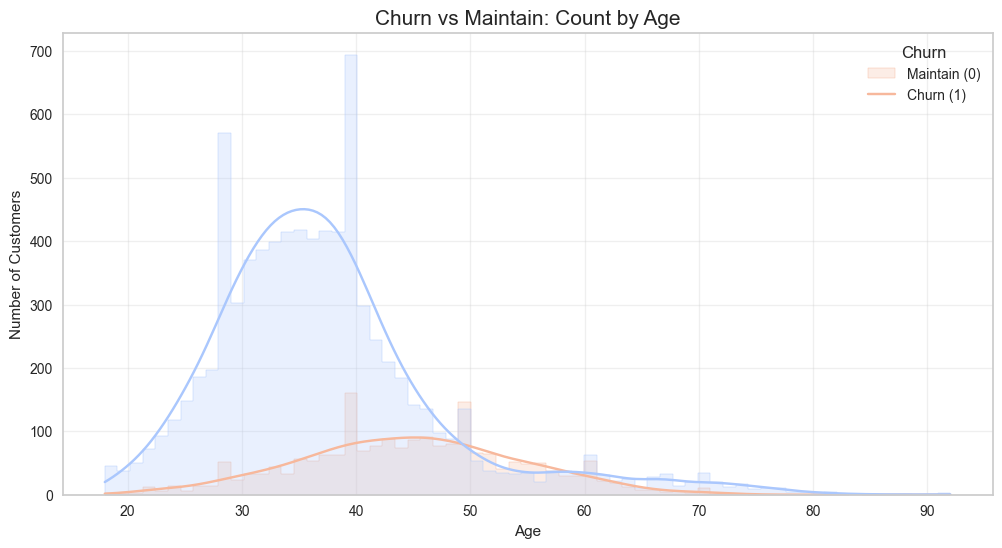

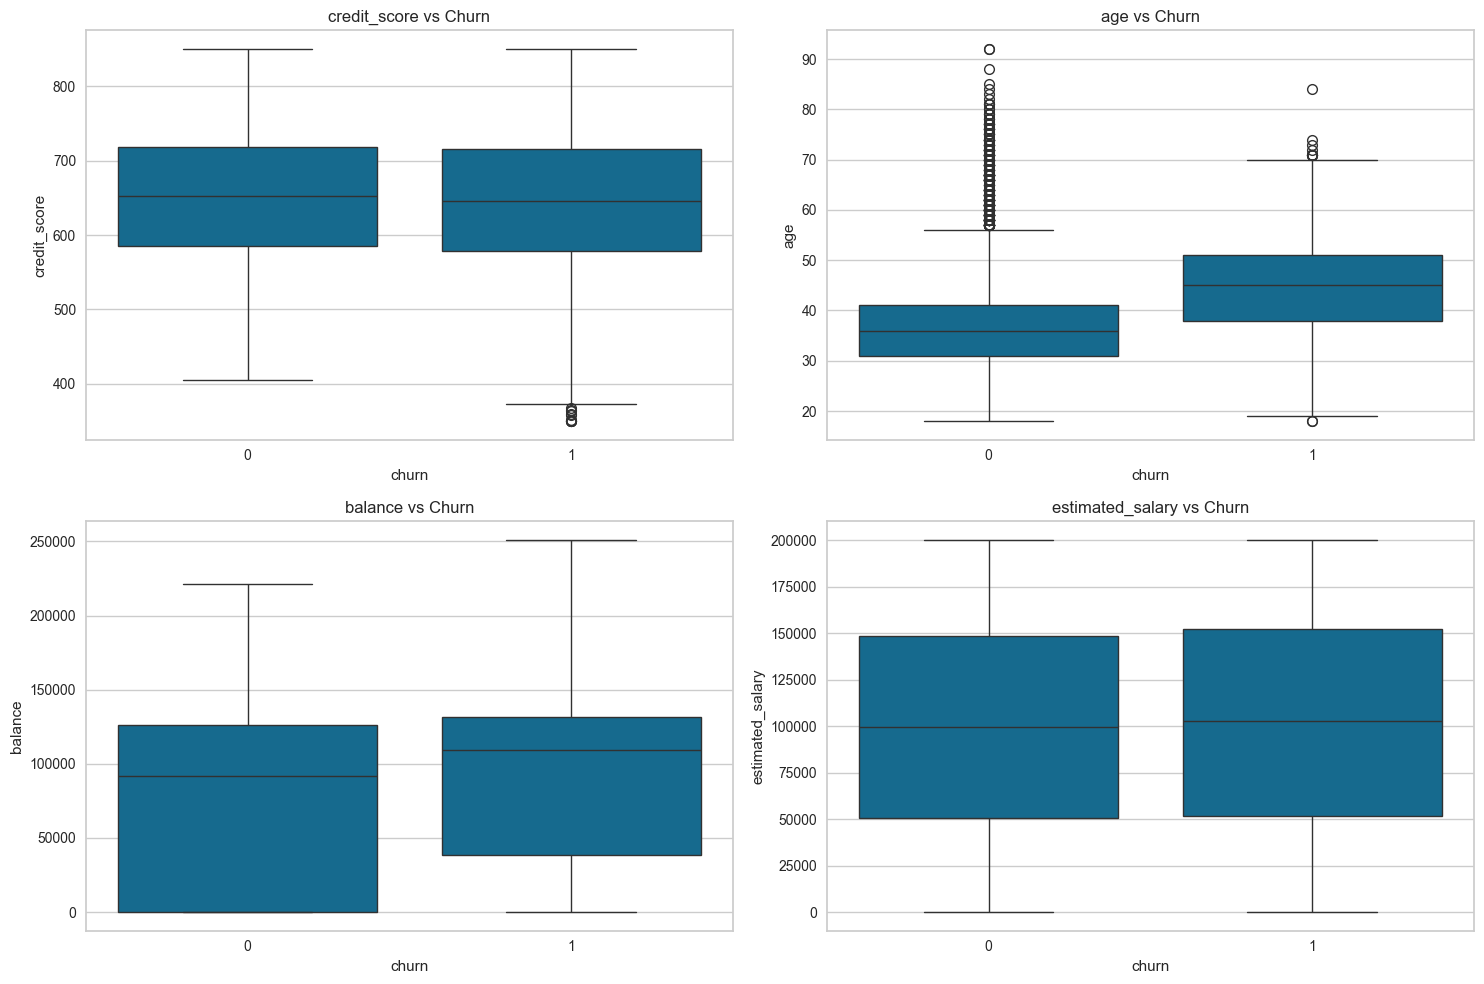

In [60]:
plt.figure(figsize=(12, 6))

# 1. 나이별 이탈(1) / 유지(0) 빈도수 시각화
sns.histplot(data=df, x='age', hue='churn', element='step', kde=True, palette='coolwarm')

plt.title('Churn vs Maintain: Count by Age', fontsize=15)
plt.xlabel('Age')
plt.ylabel('Number of Customers') # 고객 수
plt.legend(title='Churn', labels=['Maintain (0)', 'Churn (1)'])
plt.grid(True, alpha=0.3)

plt.show()

# 3. 주요 수치형 변수와 Churn의 Boxplot
cols = ['credit_score', 'age', 'balance', 'estimated_salary']
plt.figure(figsize=(15, 10))
for i, col in enumerate(cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='churn', y=col, data=df)
    plt.title(f'{col} vs Churn')
plt.tight_layout()
plt.show()



## 2. (20점) EDA를 통한 타당한 해석 (650자 이내, 주석 서술하기)

> 히스토그램 ( age를 기준으로 churn 확인 ) 0= 유지 1= 이탈
> 유지고객은 30~40대 사이에 가장 많이 분포함을 확인할 수 있고, 이탈고객은 40~50사이에 많음을 확인 -> 교차지점을 확인함
> 이는 age변수의 특정 연령층이 주된 이탈 위험군임을 시사함

> 상관계수는 전체적으로 높지않았다.
> churn과 다른 변수들을 봤을 때, gender(-0.1), age(0.28), balance(0.11), active_member(-0.15)임을 확인하였다.
> 원핫인코딩 진행 이후 해당 변수에 nation_germany(0.17)가 추가됨을 확인할 수 있었고, nation_germany의 경우 balance와 0.4의 양의상관계수를 가짐을 확인할 수 있었다.

> boxplot
> balance의 경우 유지고객은 balance = 0 인 고객이 존재하고 박스 자체가 큰데,이탈고객은 박스 자체가 작고, 중앙값은 더 높음을 확인할 수 있다. > 이는 고액 자산가 그룹의 이탈 가능성을 포착
> age자체도 churn 0일 때는 30~40 구간에 박스가 형성됨(이 쪽에 많음)을 확인하였고, 1일 때는 40~50구간에 박스가 형성됨을 확인할 수 있고, 박스자체도 0보다 1이 크며 중앙값 또한 1이 높음을 확인할 수 있다.
> credit_score와, estimated_salary의 경우 중앙값과 박스 크기자체는 크게 차이가 안나기에, 이탈 여부에 따른 분포차이가 미미함을 확인하였다. 이는 상호작용을 통한 변수활용으로 돌려도 좋아보임


In [61]:
## Age Distribution by churn
# 0= 유지 1= 이탈
# 유지는 30~40대 사이에 가장 많이 분포함을 확인할 수 있고, 이탈은 40~50사이에 많음을 확인 ->> 교차지점

## boxplot 확인했을 때,
# 유지고객은 balance =0인고객이 존재하고 박스 자체가 큰데, 이탈고객은 
# age자체도 churn 0일 때는 30~40 구간에 박스가 형성됨(이 쪽에 많음)을 확인ㅇ, 1일 때 40~50구간에 박스가 형성됨을 확인할 수 있고, 박스자체도 0보다 1이 큼을 확인할 수 있다.

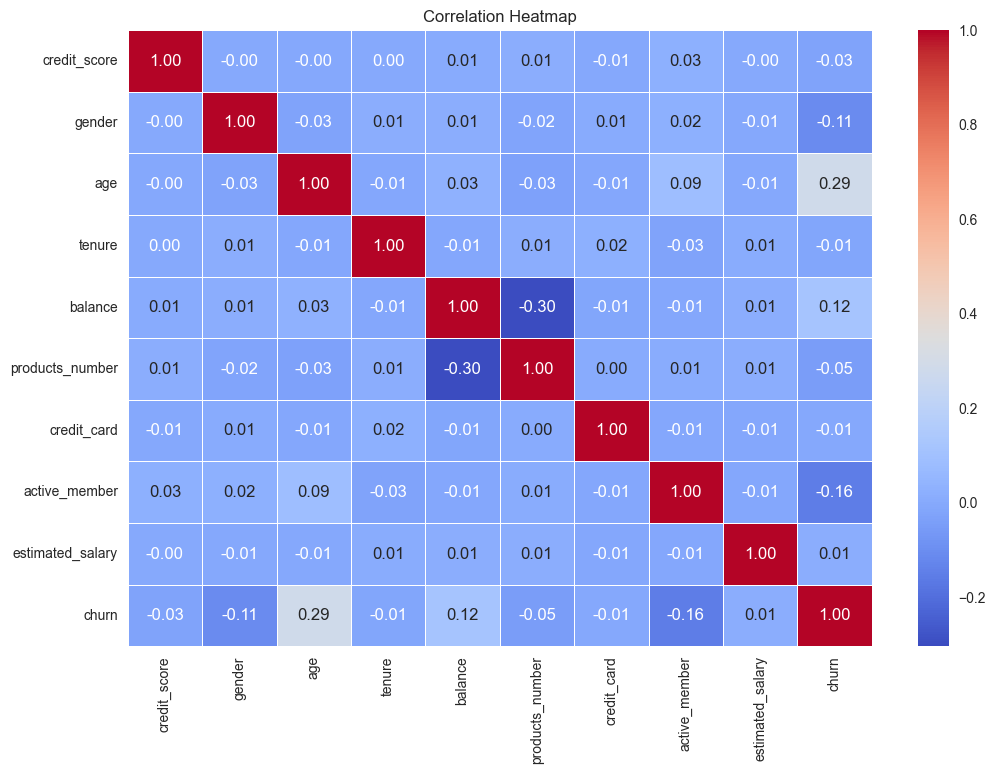

,credit_score,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,nation_Germany,nation_Spain
credit_score,1.000000,-0.002857,-0.003965,0.000842,0.006268,0.012238,-0.005458,0.025651,-0.001384,-0.027094,0.005538,0.004780
gender,-0.002857,1.000000,-0.027544,0.014733,0.012087,-0.021859,0.005766,0.022544,-0.008112,-0.106512,-0.024628,0.016889
age,-0.003965,-0.027544,1.000000,-0.009997,0.028308,-0.030680,-0.011721,0.085472,-0.007201,0.285323,0.046897,-0.001685
tenure,0.000842,0.014733,-0.009997,1.000000,-0.012254,0.013444,0.022583,-0.028362,0.007784,-0.014001,-0.000567,0.003868
balance,0.006268,0.012087,0.028308,-0.012254,1.000000,-0.304180,-0.014858,-0.010084,0.012797,0.118533,0.401110,-0.134892
products_number,0.012238,-0.021859,-0.030680,0.013444,-0.304180,1.000000,0.003183,0.009612,0.014204,-0.047820,-0.010419,0.009039
credit_card,-0.005458,0.005766,-0.011721,0.022583,-0.014858,0.003183,1.000000,-0.011866,-0.009933,-0.007138,0.010577,-0.013480
active_member,0.025651,0.022544,0.085472,-0.028362,-0.010084,0.009612,-0.011866,1.000000,-0.011421,-0.156128,-0.020486,0.016732
estimated_salary,-0.001384,-0.008112,-0.007201,0.007784,0.012797,0.014204,-0.009933,-0.011421,1.000000,0.012097,0.010297,-0.006482
churn,-0.027094,-0.106512,0.285323,-0.014001,0.118533,-0.047820,-0.007138,-0.156128,0.012097,1.000000,0.173488,-0.052667


In [62]:
# 2. corr 확인
plt.figure(figsize=(12, 8))
# 문자열 컬럼 제외하고 상관계수 계산
corr_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

#
a= df.corr()
a

In [ ]:
# churn과 gender(-0.1), age(0.28), balance(0.11), active_member(-0.15)
# 원핫인코딩 하니까? + nation_germany(0.17)

In [ ]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

# 1. 스케일링된 데이터에 상수항 추가
X_vif = sm.add_constant(pd.DataFrame(X_train_scaled, columns=X_train.columns))

# 2. VIF 계산
vif_df = pd.DataFrame()
vif_df["feature"] = X_vif.columns
vif_df["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

# 3. VIF 확인
print(vif_df[vif_df['feature'] != 'const'].sort_values(by="VIF", ascending=False))

             feature       VIF
10    nation_Germany  1.340848
5            balance  1.337182
11      nation_Spain  1.126594
6    products_number  1.125593
3                age  1.012386
8      active_member  1.010647
2             gender  1.003361
4             tenure  1.002479
7        credit_card  1.001757
9   estimated_salary  1.001499
1       credit_score  1.001041


In [17]:
#!pip uninstall scikit-learn -y


In [18]:
#!pip install scikit-learn==1.2.2

In [19]:
#pip install --upgrade pycaret

In [ ]:
from pycaret.classification import *
# 4. 데이터 분할
# train valid split + 데이터 불균형이 존재하기때문에 stratify 사용하여 이탈자 비율을 고르게 나눔
train_df, valid_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['churn']
)

# 5. PyCaret 설정 (setup 함수)
clf = setup(
    data = train_df, 
    target = 'churn', 
    session_id = 42,
    normalize = True,               # 스케일링 - 기본값 = ss
                                    # 스케일링 = 각각 변수의 범주가 다르기에, 이를 맞추기위함
    verbose = True
)


,Description,Value
0,Session id,42
1,Target,churn
2,Target type,Binary
3,Original data shape,"(8000, 12)"
4,Transformed data shape,"(8000, 12)"
5,Transformed train set shape,"(5600, 12)"
6,Transformed test set shape,"(2400, 12)"
7,Numeric features,9
8,Preprocess,True
9,Imputation type,simple


In [64]:
# 모든 모델 비교 - F1 스코어 기준 상위 4개 모델 선택
best_4_models = compare_models(sort='F1', n_select=4)

# 선택된 모델들 확인
print("선택된 상위 4개 모델:", best_4_models)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.8575,0.8491,0.4856,0.7264,0.5806,0.4990,0.5145,0.1200
gbc,Gradient Boosting Classifier,0.8625,0.8654,0.4655,0.7711,0.5786,0.5027,0.5265,0.1340
catboost,CatBoost Classifier,0.8595,0.8631,0.4733,0.7467,0.5777,0.4986,0.5182,1.0350
ada,Ada Boost Classifier,0.8550,0.8509,0.4716,0.7223,0.5690,0.4867,0.5035,0.0550
xgboost,Extreme Gradient Boosting,0.8470,0.8368,0.4883,0.6714,0.5639,0.4742,0.4838,0.0380
rf,Random Forest Classifier,0.8564,0.8432,0.4427,0.7525,0.5555,0.4771,0.5018,0.1560
et,Extra Trees Classifier,0.8532,0.8429,0.4304,0.7414,0.5435,0.4635,0.4884,0.1090
qda,Quadratic Discriminant Analysis,0.8362,0.8158,0.3865,0.6706,0.4886,0.3999,0.4222,0.0120
dt,Decision Tree Classifier,0.7848,0.6813,0.5067,0.4737,0.4885,0.3527,0.3537,0.0130
nb,Naive Bayes,0.8234,0.7925,0.3585,0.6140,0.4513,0.3551,0.3739,0.0130


선택된 상위 4개 모델: [LGBMClassifier(boosting_type='gbdt', class_weight=None, colsample_bytree=1.0,
               importance_type='split', learning_rate=0.1, max_depth=-1,
               min_child_samples=20, min_child_weight=0.001, min_split_gain=0.0,
               n_estimators=100, n_jobs=-1, num_leaves=31, objective=None,
               random_state=42, reg_alpha=0.0, reg_lambda=0.0, subsample=1.0,
               subsample_for_bin=200000, subsample_freq=0), GradientBoostingClassifier(ccp_alpha=0.0, criterion='friedman_mse', init=None,
                           learning_rate=0.1, loss='log_loss', max_depth=3,
                           max_features=None, max_leaf_nodes=None,
                           min_impurity_decrease=0.0, min_samples_leaf=1,
                           min_samples_split=2, min_weight_fraction_leaf=0.0,
                           n_estimators=100, n_iter_no_change=None,
                           random_state=42, subsample=1.0, tol=0.0001,
                           

In [81]:
import optuna
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.tree import DecisionTreeClassifier

In [65]:
# 하이퍼파라미터 탐색
model = RandomForestClassifier()
print(model.get_params())

{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': None, 'verbose': 0, 'warm_start': False}


In [66]:
train_df.head(3)

,credit_score,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,nation_Germany,nation_Spain
2151,753,1,57,7,0.00,1,1,0,159475.08,1,False,False
8392,739,1,32,3,102128.27,1,1,0,63981.37,1,True,False
5006,755,0,37,0,113865.23,2,1,1,117396.25,0,True,False


In [67]:
# 1. 학습 데이터(train_df)에서 X, y 분리
X_train = train_df.drop('churn', axis=1)
y_train = train_df['churn']

# 2. 검증 데이터(valid_df)에서 X, y 분리
X_valid = valid_df.drop('churn', axis=1)
y_valid = valid_df['churn']

# 3. 스케일링 (StandardScaler) 적용
# 스케일링은 clf에 드가있던거니까 따로 적용시켜줘야함
ss = StandardScaler()

X_train_scaled = ss.fit_transform(X_train) # train_d을 학습 + 변환
X_valid_scaled = ss.transform(X_valid) # valid_df는 변환만 (누수방지)

# 확인용 출력
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_valid_scaled shape: {X_valid_scaled.shape}")

X_train_scaled shape: (8000, 11)
X_valid_scaled shape: (2000, 11)


In [ ]:
# 스케일링 잘됐나 확인
X_train_scaled

array([[ 1.058568  ,  0.90750738,  1.71508648, ...,  1.04208392,
        -0.57831252, -0.57773517],
       [ 0.91362605,  0.90750738, -0.65993547, ..., -0.62355635,
         1.72916886, -0.57773517],
       [ 1.07927399, -1.10191942, -0.18493108, ...,  0.30812779,
         1.72916886, -0.57773517],
       ...,
       [ 0.16821031, -1.10191942, -0.18493108, ..., -0.55808767,
        -0.57831252, -0.57773517],
       [ 0.37527024,  0.90750738, -0.37493284, ..., -1.35149956,
        -0.57831252,  1.73089688],
       [ 1.56586482,  0.90750738,  1.14508121, ..., -1.02692216,
        -0.57831252,  1.73089688]])

In [ ]:
# 상위모델 4개 고른 것을, 각 모델 optuna로 최적의 파라미터 찾기 == 정밀 튜닝

# 1. AdaBoost
# def objective_ada(trial):
#     params = {
#         'n_estimators': trial.suggest_int('n_estimators', 50, 300), # 트리개수
#         'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.5), # 학습률
#     }
#     model = AdaBoostClassifier(**params, random_state=42)
#     model.fit(X_train_scaled, y_train)
#     return f1_score(y_valid, model.predict(X_valid_scaled))

# 2. GradientBoosting
def objective_gbc(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300), #트리개수
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),# 학습률
        'max_depth': trial.suggest_int('max_depth', 3, 8) #트리 최대 깊이
    }
    model = GradientBoostingClassifier(**params, random_state=42)
    model.fit(X_train_scaled, y_train)
    return f1_score(y_valid, model.predict(X_valid_scaled))

# 3. LightGBM - 규제가능
def objective_lgbm(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500), # 트리개수
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3), # 학습률
        'num_leaves': trial.suggest_int('num_leaves', 20, 150), #
        'max_depth': trial.suggest_int('max_depth', 3, 12), #최대깊이
#        'class_weight': trial.suggest_categorical('class_weight', ['balanced', None])
#        # 데이터 불균형으로 인해 증강 전 먼저 class_weight추가 해봄 >> 이는 후방모델에만 적용시키는게 더 높아서 주석처리
    }
    model = LGBMClassifier(**params, random_state=42, verbose=-1) # verbose= 로그 출력을 줄여 깔끔하게 보여줌
    model.fit(X_train_scaled, y_train)
    return f1_score(y_valid, model.predict(X_valid_scaled))

# # 4. CatBoost (원핫인코딩 하니까 rf가 밀려나서 catboost사용해봄)
# def objective_cat(trial):
#     params = {
#         'iterations': trial.suggest_int('iterations', 100, 500), # 트리 개수
#         'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3), # 학습률
#         'depth': trial.suggest_int('depth', 4, 10), # 트리 깊이
#         'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 10.0), # L2 규제
#         'random_seed': 42,
#         'verbose': False # 학습 로그 생략
#     }
#     model = CatBoostClassifier(**params)
#     model.fit(X_train_scaled, y_train)
#     return f1_score(y_valid, model.predict(X_valid_scaled))

# 4. RandomForest
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_depth': trial.suggest_int('max_depth', 5, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10), # 노드를 분할하기 위한 최소 샘플 수 
#        'class_weight': trial.suggest_categorical('class_weight', ['balanced', 'balanced_subsample', None])
    }
    model = RandomForestClassifier(**params, random_state=42)
    model.fit(X_train_scaled, y_train)
    return f1_score(y_valid, model.predict(X_valid_scaled))

# 4. Decision Tree 튜닝 (조커 모델용)
def objective_dt(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 15), # 너무 깊으면 과적합되니 주의
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy'])
    }
    model = DecisionTreeClassifier(**params, random_state=42)
    model.fit(X_train_scaled, y_train)
    return f1_score(y_valid, model.predict(X_valid_scaled))


In [ ]:
# 최적화 실행
# study_ada = optuna.create_study(direction='maximize')
# study_ada.optimize(objective_ada, n_trials=15)

study_gbc = optuna.create_study(direction='maximize')
study_gbc.optimize(objective_gbc, n_trials=15)

study_lgbm = optuna.create_study(direction='maximize')
study_lgbm.optimize(objective_lgbm, n_trials=15)

study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=15)

study_dt = optuna.create_study(direction='maximize')
study_dt.optimize(objective_dt, n_trials=15)

# study_cat = optuna.create_study(direction='maximize')
# study_cat.optimize(objective_cat, n_trials=15)

[I 2026-04-09 16:23:20,880] A new study created in memory with name: no-name-f65c501e-58c9-47d2-ba2f-2ca242dbf205
[I 2026-04-09 16:23:21,715] Trial 0 finished with value: 0.47719298245614034 and parameters: {'n_estimators': 166, 'learning_rate': 0.052019896809436646}. Best is trial 0 with value: 0.47719298245614034.
[I 2026-04-09 16:23:22,833] Trial 1 finished with value: 0.5731523378582202 and parameters: {'n_estimators': 214, 'learning_rate': 0.33701970437042283}. Best is trial 1 with value: 0.5731523378582202.
[I 2026-04-09 16:23:23,812] Trial 2 finished with value: 0.5714285714285714 and parameters: {'n_estimators': 184, 'learning_rate': 0.3412603315629741}. Best is trial 1 with value: 0.5731523378582202.
[I 2026-04-09 16:23:25,244] Trial 3 finished with value: 0.5705705705705706 and parameters: {'n_estimators': 277, 'learning_rate': 0.29266177262079685}. Best is trial 1 with value: 0.5731523378582202.
[I 2026-04-09 16:23:25,813] Trial 4 finished with value: 0.5803571428571429 and 

In [85]:
# 최적 파라미터로 최종 모델 정의
# ada_final = AdaBoostClassifier(**study_ada.best_params, random_state=42)
gbc_final = GradientBoostingClassifier(**study_gbc.best_params, random_state=42)
lgbm_final = LGBMClassifier(**study_lgbm.best_params, random_state=42, verbose=-1)
rf_final = RandomForestClassifier(**study_rf.best_params, random_state=42)
dt_final = DecisionTreeClassifier(**study_dt.best_params, random_state=42)
#cat_final = CatBoostClassifier(**study_cat.best_params, random_seed=42, verbose=False, allow_writing_files=False)

In [ ]:
from sklearn.metrics import accuracy_score
# 1. 전방 모델 리스트 (최적화 모델들)
# est_model_list = [
#     ('ada', ada_final),
#     ('gbc', gbc_final),
#     ('lgbm', lgbm_final),
# #    ('rf', rf_final)
#     ('cat', cat_final)
# ]

# 에이스(LGBM, GBC) + 조커(DT) + 다양성(RF) 조합
est_model_list = [
    ('lgbm', lgbm_final),
    ('gbc', gbc_final),
    ('rf', rf_final),
    ('dt', DecisionTreeClassifier(max_depth=5, random_state=42))
]

stack_model = StackingClassifier(
    estimators = est_model_list,
    final_estimator = LogisticRegression(class_weight='balanced'),
    # logistic에 class_weight= balance로 가중치를 두어 불균형 맞춰보기
    cv = 5 # *5
)

# 학습
stack_model.fit(X_train_scaled, y_train)

# 3. 최종 결과 출력
stack_pred = stack_model.predict(X_valid_scaled)
print("--- [최종 결과] ---")
print(f"Stacking F1-Score: {f1_score(y_valid, stack_pred):.4f}")
print(f"Stacking Accuracy: {accuracy_score(y_valid, stack_pred):.4f}")

--- [최종 결과] ---
Stacking F1-Score: 0.6350
Stacking Accuracy: 0.8350


In [ ]:
# 기본 스태킹 모델링(라벨인코딩)
# Stacking F1-Score: 0.5997

# 클래스불균형 해소(증강 대신 class_weight='balanced') (라벨인코딩)
# == Stacking F1-Score: 0.6310

# 원핫인코딩 이후 모델 재설정 + 클래스 불균형 해소
# Stacking F1-Score: 0.6293

# 원핫+ 재설정모델+클래스불균형해소+ 전방모델(lgbm)에도 balance추가해봄
# Stacking F1-Score: 0.6166 >> 너무예민해진듯?

# 진짜마지막 cat빼고 lgbm, gbc(성능좋은 2), rf(다양성.), dt(recall 높음)으로 진행
# Stacking F1-Score: 0.6350

## 3. (25점) Feature Selection과 ML 선정 기준 (650자 이내, 주석 서술하기)

> 원핫인코딩을 한 후 결과를 보았을 때, 낮은 상관관계 속에서도 nation germany 가 0.17로 상대적으로 높은 수치의 corr을 가짐을 확인하여 원핫인코딩을 한 데이터를 선택함

> vif를 확인해 본 결과, 모든 변수가 1에 가까운 값을 가져 모델의 왜곡위험은 없다고 판단하였고, 일단 모든 데이터를 다 넣어 데이터 가치를 극대화하는 전략을 취했음

> ML선정

> 1단계 : 부스팅모델 중심의 스태킹으로 시작 = f1score 0.59  
> 2단계 : 클래스 불균형 보정(증강대신 class_weight='balanced', 후방모델에 가중치 부여)  
> 3단계 : 원핫인코딩 진행 + 구조개선(원핫인코딩 적용 및 전/후방 중복 가중치 실험) 전후방으로 다 주면 너무 예민해져서 최적의 가중치 밸런스 도출  
> 최종 : lgbm, gbc(쭉 성능 좋았던 2), rf(배깅 :: 다양성, 예측안정성), dt(recall 제일 높음)  
> 모든 모델은 optuna로 하이퍼파라미터 튜닝을 거쳤고, 최종적으로 f1score은 0.6350을 도출함.

> 파생변수나 전처리쪽에 더 신경을 쓴다면 더 높은 점수도 가능해보임  
> + 우리가 진짜 잡아야 할 것은 이탈자로, 이에대한 정확도를 더 올리고자 f1score을 높이는 모델링을 진행했음

In [94]:
# 1. SHAP 전용 모델 생성 (최종 모델의 '가중치 전략'을 그대로 복사)
# Optuna로 찾은 파라미터는 lgbm_final.get_params()로 가져올 수 있습니다.
analysis_model = LGBMClassifier(**lgbm_final.get_params())
analysis_model.set_params(class_weight='balanced') # 여기서 가중치 강제 주입

# 2. 다시 학습
analysis_model.fit(X_train_scaled, y_train)


LGBMClassifier(boosting_type='gbdt', class_weight='balanced',
               colsample_bytree=1.0, importance_type='split',
               learning_rate=0.09131872729528773, max_depth=3,
               min_child_samples=20, min_child_weight=0.001, min_split_gain=0.0,
               n_estimators=141, n_jobs=None, num_leaves=136, objective=None,
               random_state=42, reg_alpha=0.0, reg_lambda=0.0, subsample=1.0,
               subsample_for_bin=200000, subsample_freq=0, verbose=-1)

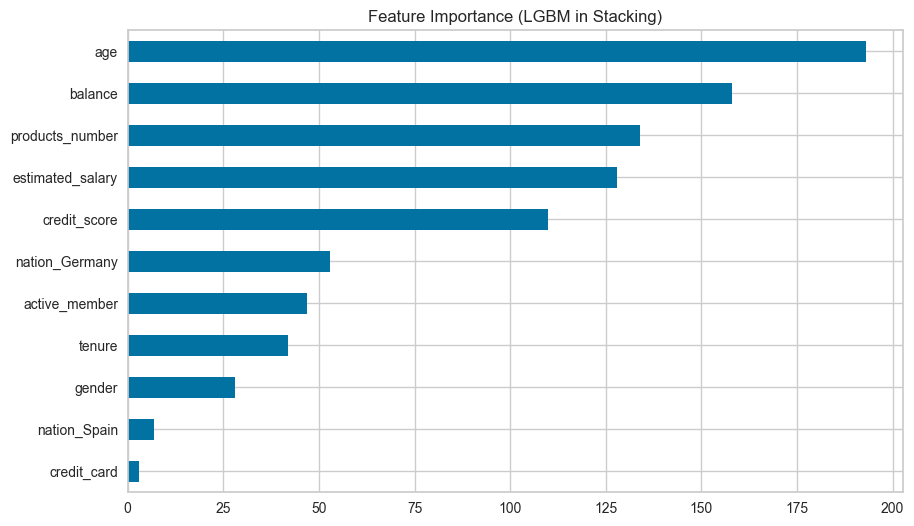

In [95]:
import matplotlib.pyplot as plt
import pandas as pd

# 스태킹 모델 내 LGBM의 중요도 확인 예시
lgbm_model = stack_model.estimators_[0] # 리스트 순서에 따라 인덱스 확인
ft_importance = pd.Series(lgbm_model.feature_importances_, index=X_train.columns)

plt.figure(figsize=(10, 6))
ft_importance.sort_values().plot(kind='barh')
plt.title('Feature Importance (LGBM in Stacking)')
plt.show()

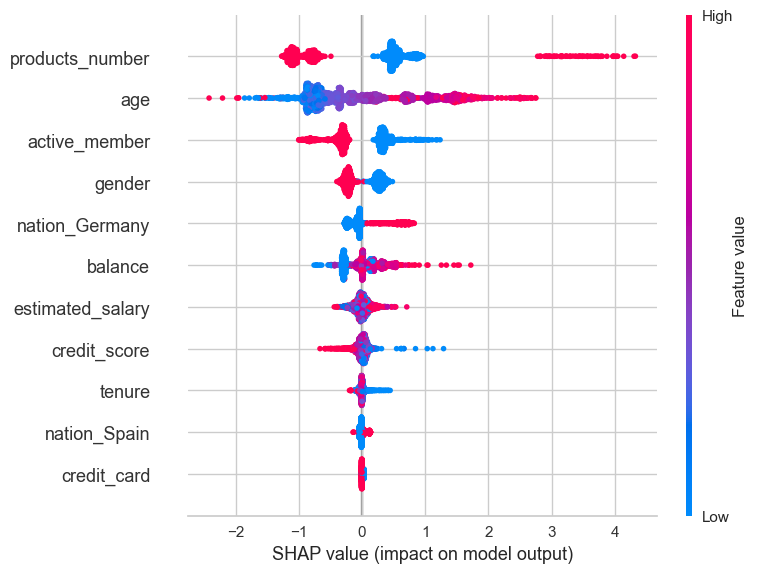

In [96]:

# 3. SHAP 분석
explainer = shap.TreeExplainer(analysis_model)
shap_values = explainer.shap_values(X_valid_scaled)

# 2. 차원 보정 (교재 및 수업 내용 반영)
if isinstance(shap_values, list):
    # 리스트 형태면 보통 [0:유지, 1:이탈]이므로 1번 인덱스 추출
    shap_values = shap_values[1] 
elif shap_values.ndim == 3:
    shap_values = shap_values[:, :, 1]

# 3. SHAP 시각화
# feature_names는 원래 데이터프레임의 컬럼명을 넣어줘야 해석이 가능함
shap.summary_plot(
    shap_values, 
    X_valid_scaled, 
    feature_names=X_train.columns)

# 추가사후분석

In [ ]:
# 어케 젠더가 저렇게 뚜렷하게? 나온거지 # active_member + nation_germany도 어케 저래 뚜렷해? 확인

df.groupby('gender')['churn'].value_counts()
# 0=female, 1=male
# 0의 이탈률 = 1139/4543 = 25%
# 1의 이탈률 = 898/5457 = 16.45

gender  churn
0       0        3404
        1        1139
1       0        4559
        1         898
Name: count, dtype: int64

In [100]:
# 1. 활동성(active_member)에 따른 이탈률
active_churn = df.groupby('active_member')['churn'].mean()
print("--- [활동성별 이탈률] ---")
print(active_churn)
print()

# 2. 독일 거주 여부(nation_Germany)에 따른 이탈률
germany_churn = df.groupby('nation_Germany')['churn'].mean()
print("--- [독일 거주 여부별 이탈률] ---")
print(germany_churn)

--- [활동성별 이탈률] ---
active_member
0    0.268509
1    0.142691
Name: churn, dtype: float64

--- [독일 거주 여부별 이탈률] ---
nation_Germany
False    0.163263
True     0.324432
Name: churn, dtype: float64


In [105]:

df.groupby('products_number')['churn'].value_counts()

products_number  churn
1                0        3675
                 1        1409
2                0        4242
                 1         348
3                1         220
                 0          46
4                1          60
Name: count, dtype: int64

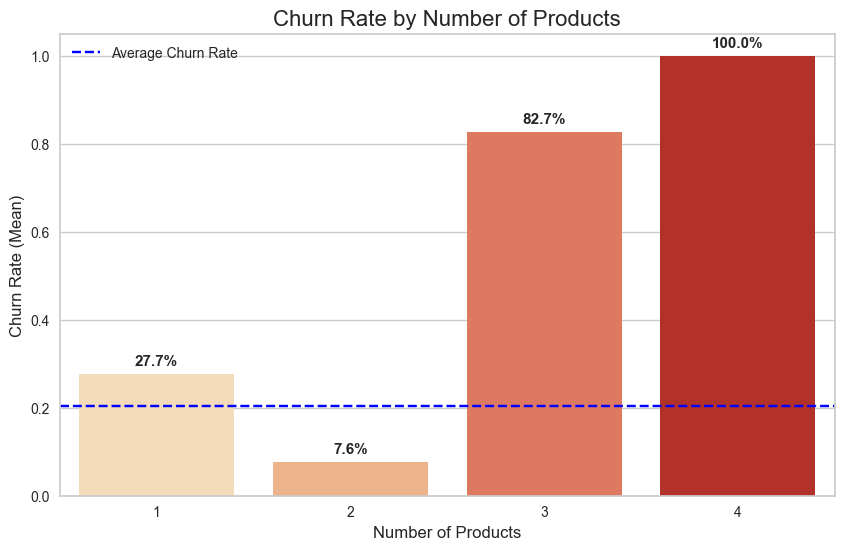

In [97]:
# 사후분석- products_number 높은애들 추출해서 특징보기
# 1. 이용상품수(products_number)별 이탈률(churn) 계산
churn_rate_by_products = df.groupby('products_number')['churn'].mean().reset_index()

# 2. 시각화 (Bar Plot)
plt.figure(figsize=(10, 6))
sns.barplot(x='products_number', y='churn', data=churn_rate_by_products, palette='OrRd')

plt.title('Churn Rate by Number of Products', fontsize=16)
plt.xlabel('Number of Products', fontsize=12)
plt.ylabel('Churn Rate (Mean)', fontsize=12)
plt.axhline(y=df['churn'].mean(), color='blue', linestyle='--', label='Average Churn Rate') # 전체 평균선
plt.legend()

# 수치 표시 추가 (바 위에 비율 적어주기)
for i, row in churn_rate_by_products.iterrows():
    plt.text(i, row['churn'] + 0.02, f"{row['churn']:.1%}", ha='center', fontsize=11, fontweight='bold')

plt.show()

In [98]:
churn_rate_by_products

,products_number,churn
0,1,0.277144
1,2,0.075817
2,3,0.827068
3,4,1.000000


--- [국가별 잔액 통계] ---
                  mean     median           std  count
country                                               
France    62092.636516   62153.50  64133.565524   5014
Germany  119730.116134  119703.10  27022.006157   2509
Spain     61818.147763   61710.44  64235.555208   2477


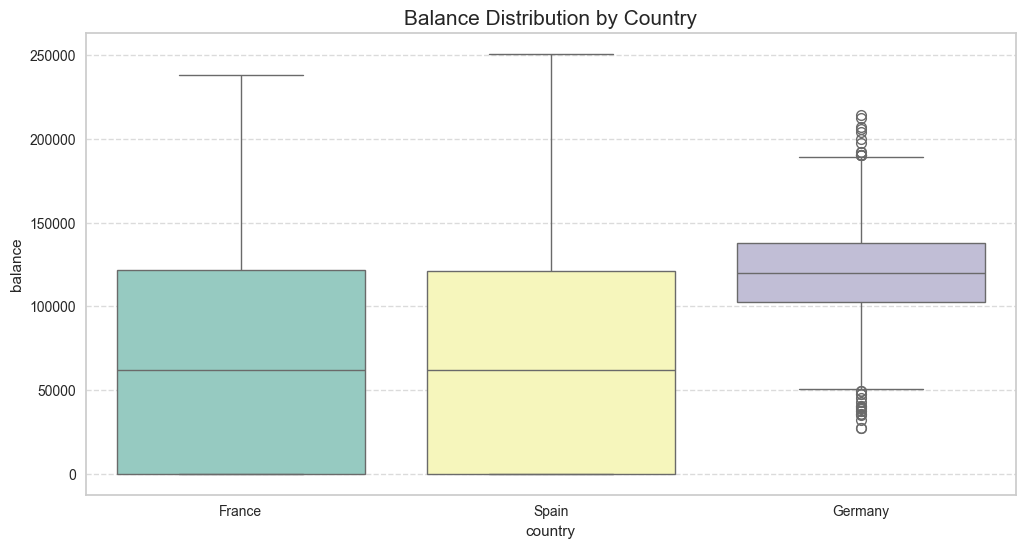

In [104]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 국가별 잔액(Balance) 기술통계량 확인
# (원핫 인코딩 전의 'country' 컬럼이 있다면 사용, 없다면 nation_ 변수들로 역산 가능)
# 여기서는 시각화를 위해 country별로 묶어서 보겠습니다.
country_balance = df.groupby('country')['balance'].agg(['mean', 'median', 'std', 'count'])
print("--- [국가별 잔액 통계] ---")
print(country_balance)

# 2. 국가별 잔액 분포 시각화 (Boxplot + Stripplot)
plt.figure(figsize=(12, 6))
sns.boxplot(x='country', y='balance', data=df, palette='Set3')

plt.title('Balance Distribution by Country', fontsize=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 4. (25점) SHAP value 사후분석과 인사이트 제안 (650자 이내, 주석 서술하기)

> feature importance와 shap를 교차확인 하였을 때, age와 products_number(상품수)가 모델의 의사결정에 가장 결정적 역할을 수행함을 확인할 수 있고, 특히 age는 학습 기여도가 1위임과 동시에, 연령대가 높을수록 이탈확률을 높이는 양의 영향력(SHAP)을 보인다.

> nation_Germany의 경우 독일에 거주할수록 이탈확률을 높이는 양의 영향력을 보인다.

> balance의 경우 피처임포턴스가 높지만, shap에서는 다소 분산된 결과임을 확인할 수 있음

> products_number, active_member, gender의 shap를 확인해 본 결과 대체적으로는 해당변수가 높을수록 이탈률이 낮아지고, 해당변수가 낮을수록 이탈률이 높아짐을 확인할 수 있었는데, 이용상품수의 경우엔 예외의 경우가 존재함을 확인하였고, 이는 사후분석을 진행해 본 결과, 보유상품이 4인 고객은 60명 모두 이탈함을 확인하였다.
> 이는 상품 가입의 역설 구간이 존재함을 시사. 2개이하 보유고객의 만족도를 높여 핵심 단골로 유지하는것이 효율적으로 보임(3개이상의 고객 약 300명)

> 4~50대 고령층에서 이탈밀도가 급격히 상승함을 포착, 이에 고령층 특화 자산관리 서비스가 시급해보임

> 타 국가 대비 독일 고객 이탈률이 2배 높은데, 이들은 고액 잔액 보유자이기에 독일 시장의 금리 경쟁력이나 프리미엄 멤버십 혜택을 전면 재검토할 필요성이 있어보임

> 여성의 경우 이탈률이 25%, 남성의 경우 16.5%로 여성이탈률이 1.5배 높기에, 여성고객군이 느끼는 서비스 불편사항을 개선하거나 선호하는 혜택을 추가 하는 등 성별 맞춤형 캠페인 필요해보임


# 5. (5점 ) validation score 적절하게 출력 (300자 이내, 주석 서술하기)

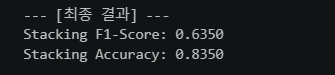
> 이탈 고객을 더 잘 잡아내는 모델을 만들기 위해 정밀도와 재현율을 모두 고려하는 f1score을 높이는 방향으로 모델링을 진행하였고,
> 정확도는 0.83, f1score은 0.635으로 마무리하였다.